# Random Forests

A Random Forest is a supervised learning algorithm. It has two variations; one is used for classification problems and the other is used for regression problems.

Random Forests work by training decision trees on the given data sample, getting a prediction from each tree, then selecting the best solution by means of voting. It is also a pretty good indicator of feature importance. In the random forest classifier, the higher the number of trees in the forest results in higher accuracy.

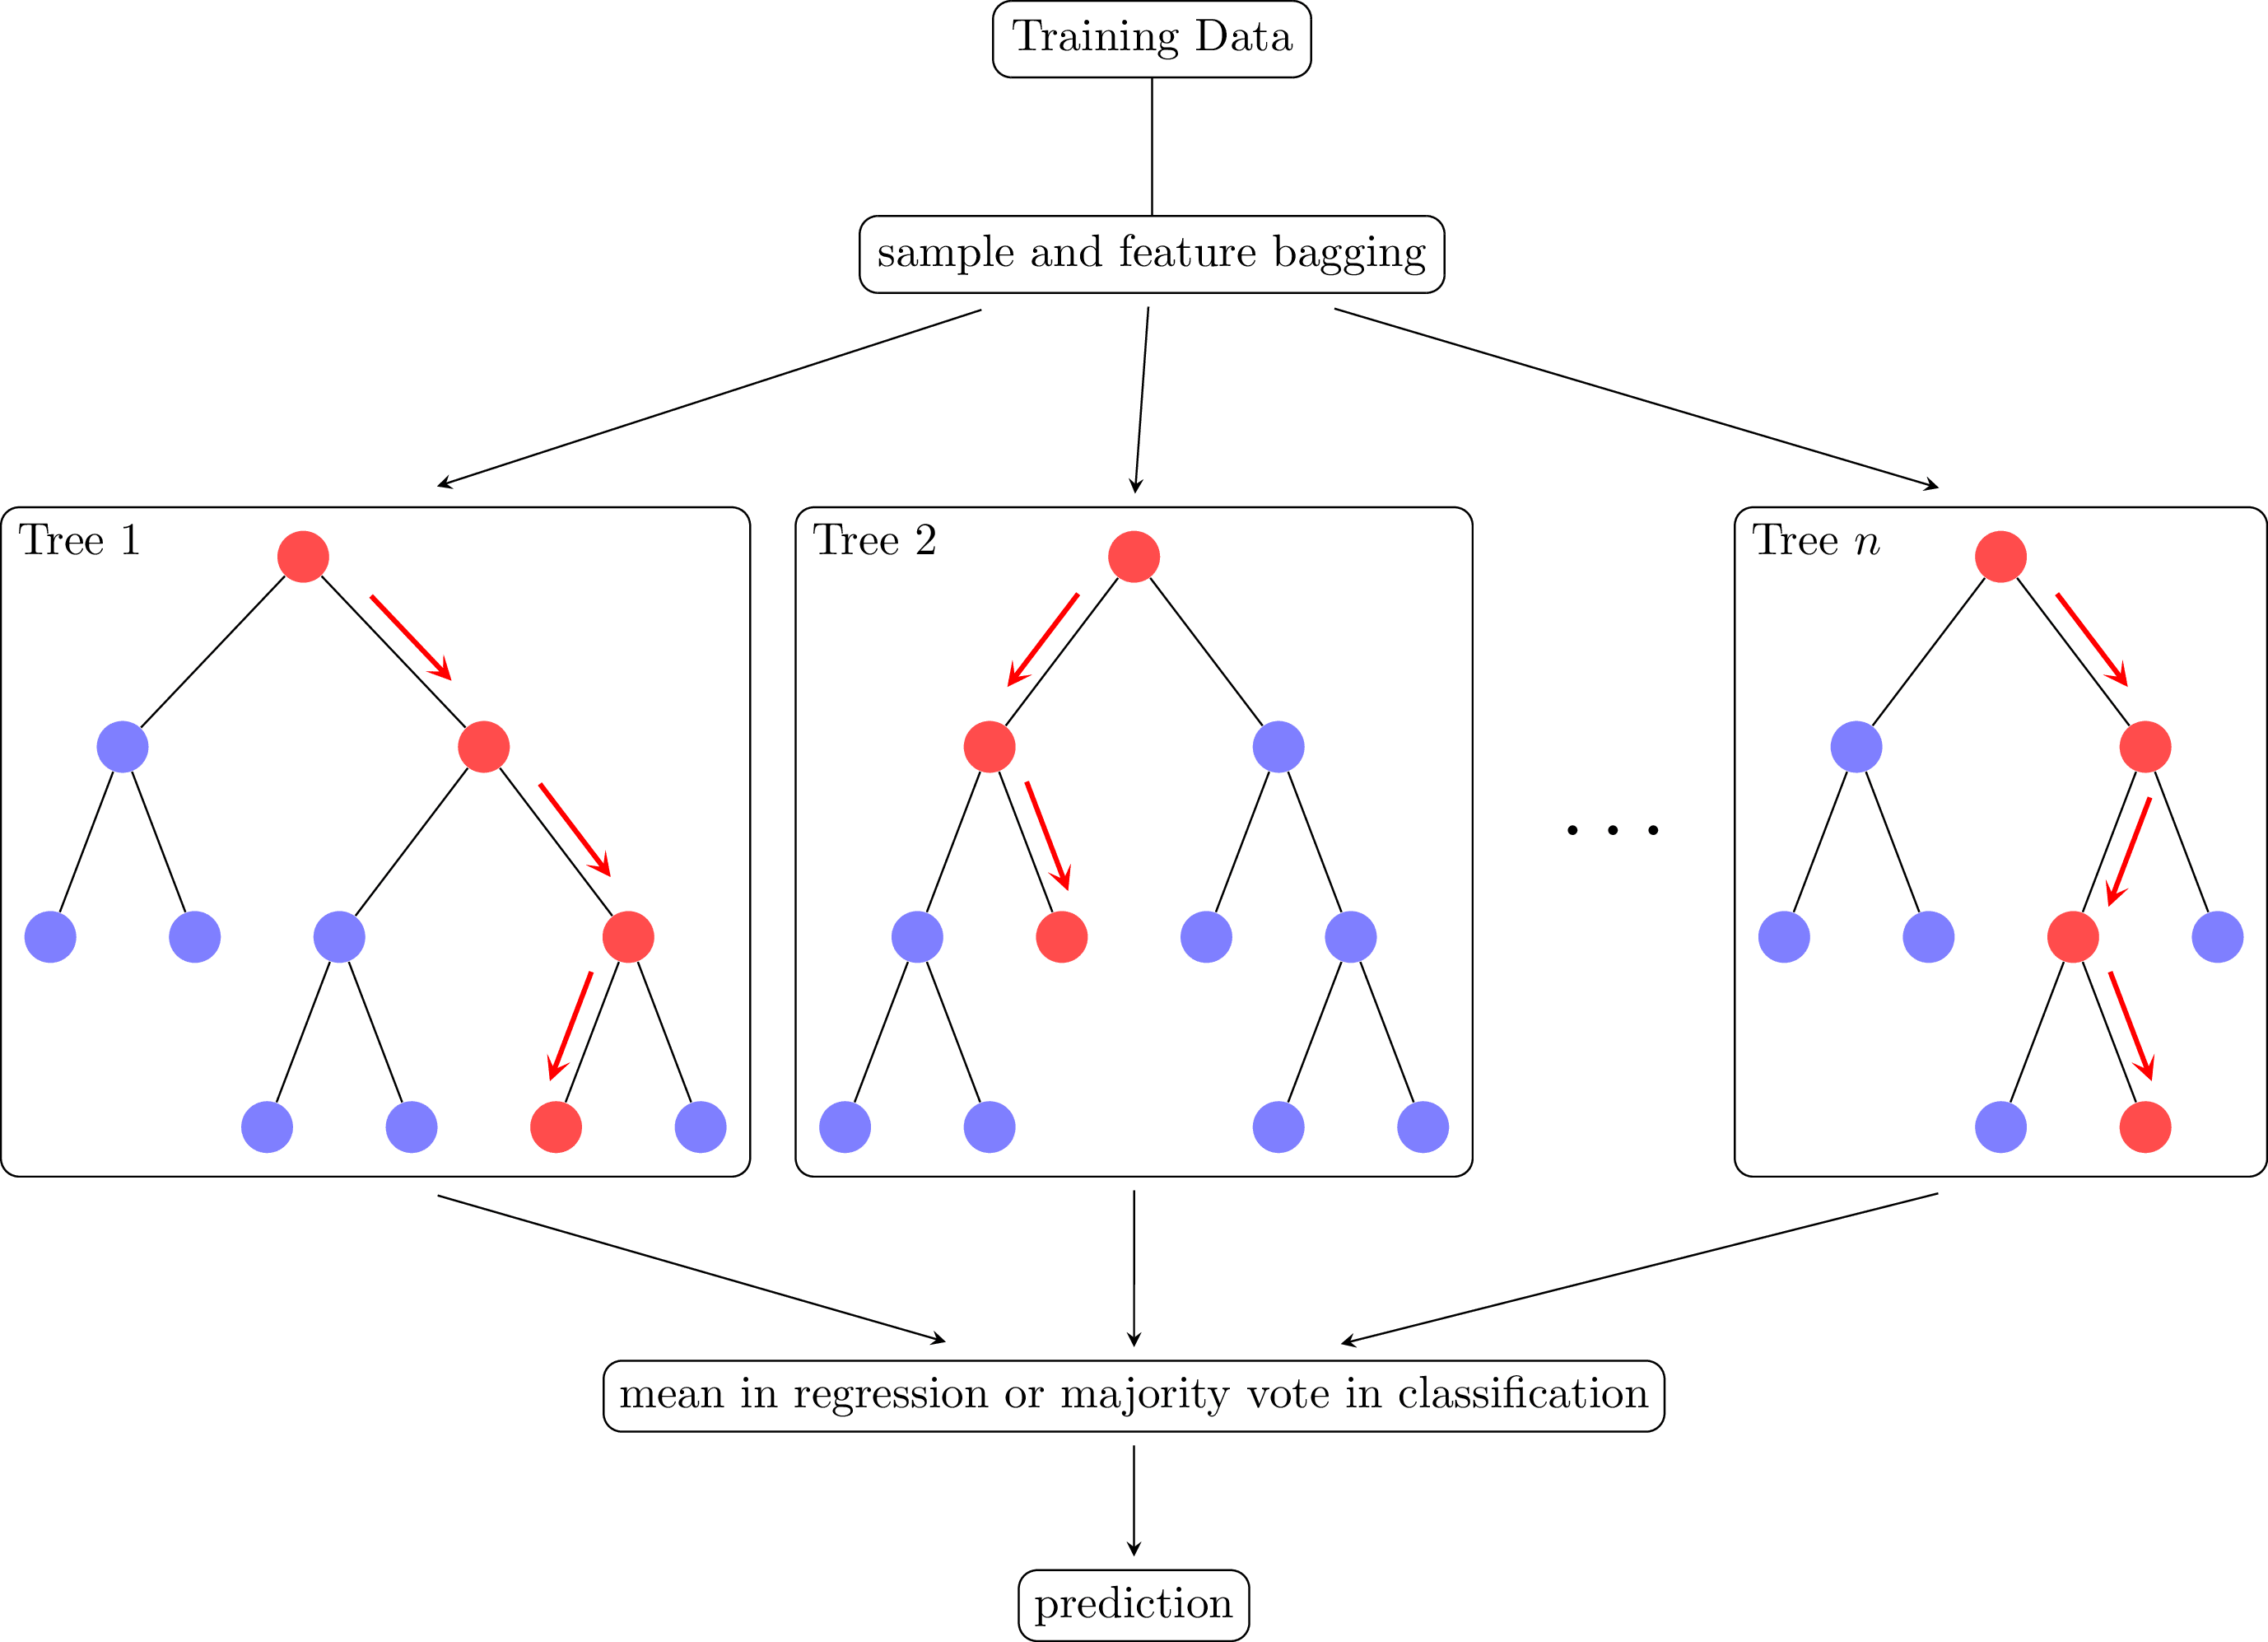

The advantages of Random forest algorithm are as follows:-

1. Can be used to solve both classification and regression problems.
2. Considered as very accurate and robust model.
3. Takes the average of all the predictions made by Decision trees, which cancels out the biases.
4. Does not suffer from the overfitting problem Decision Tress on their own have.
6. Can be used for feature selection.

The disadvantages of Random Forest algorithm are listed below:-

1. High computational complexity.
2. Difficult to interpret as compared to a Decision Tree.


✍🏼 In order to edit this notebook, make a copy and save it in your Google Drive.

## Set-Up and Preprocessing

In this notebook, we're going to be using Random Forest classification to predict users that will purchase a product based on data scraped from social media.

💾 Download the Social Network Ads dataset [here](https://www.kaggle.com/datasets/rakeshrau/social-network-ads).

👀 Let's visualize our changes:

In [4]:
# Import necessary libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
# Import the dataset

df = pd.read_csv('Social_Network_Ads.csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


✅ **Try it yourself**: Split the data into your features (`X`) and your target (`y`). The features should include `Gender`, `Age`, and `EstimatedSalary`, whereas the target should be `Purchased`. Then use one hot encoding for the gender column.

In [6]:
# Your Code Here

X = df[['Gender', 'Age', 'EstimatedSalary']]
y = df[['Purchased']]

X = pd.get_dummies(X, columns = ['Gender'])

X.head()

,Age,EstimatedSalary,Gender_Female,Gender_Male
0,19,19000,False,True
1,35,20000,False,True
2,26,43000,True,False
3,27,57000,True,False
4,19,76000,False,True


✅ **Try it yourself**: Split the data into the training and test set with 75% of data being used for training.

In [7]:
# Your Code Here
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

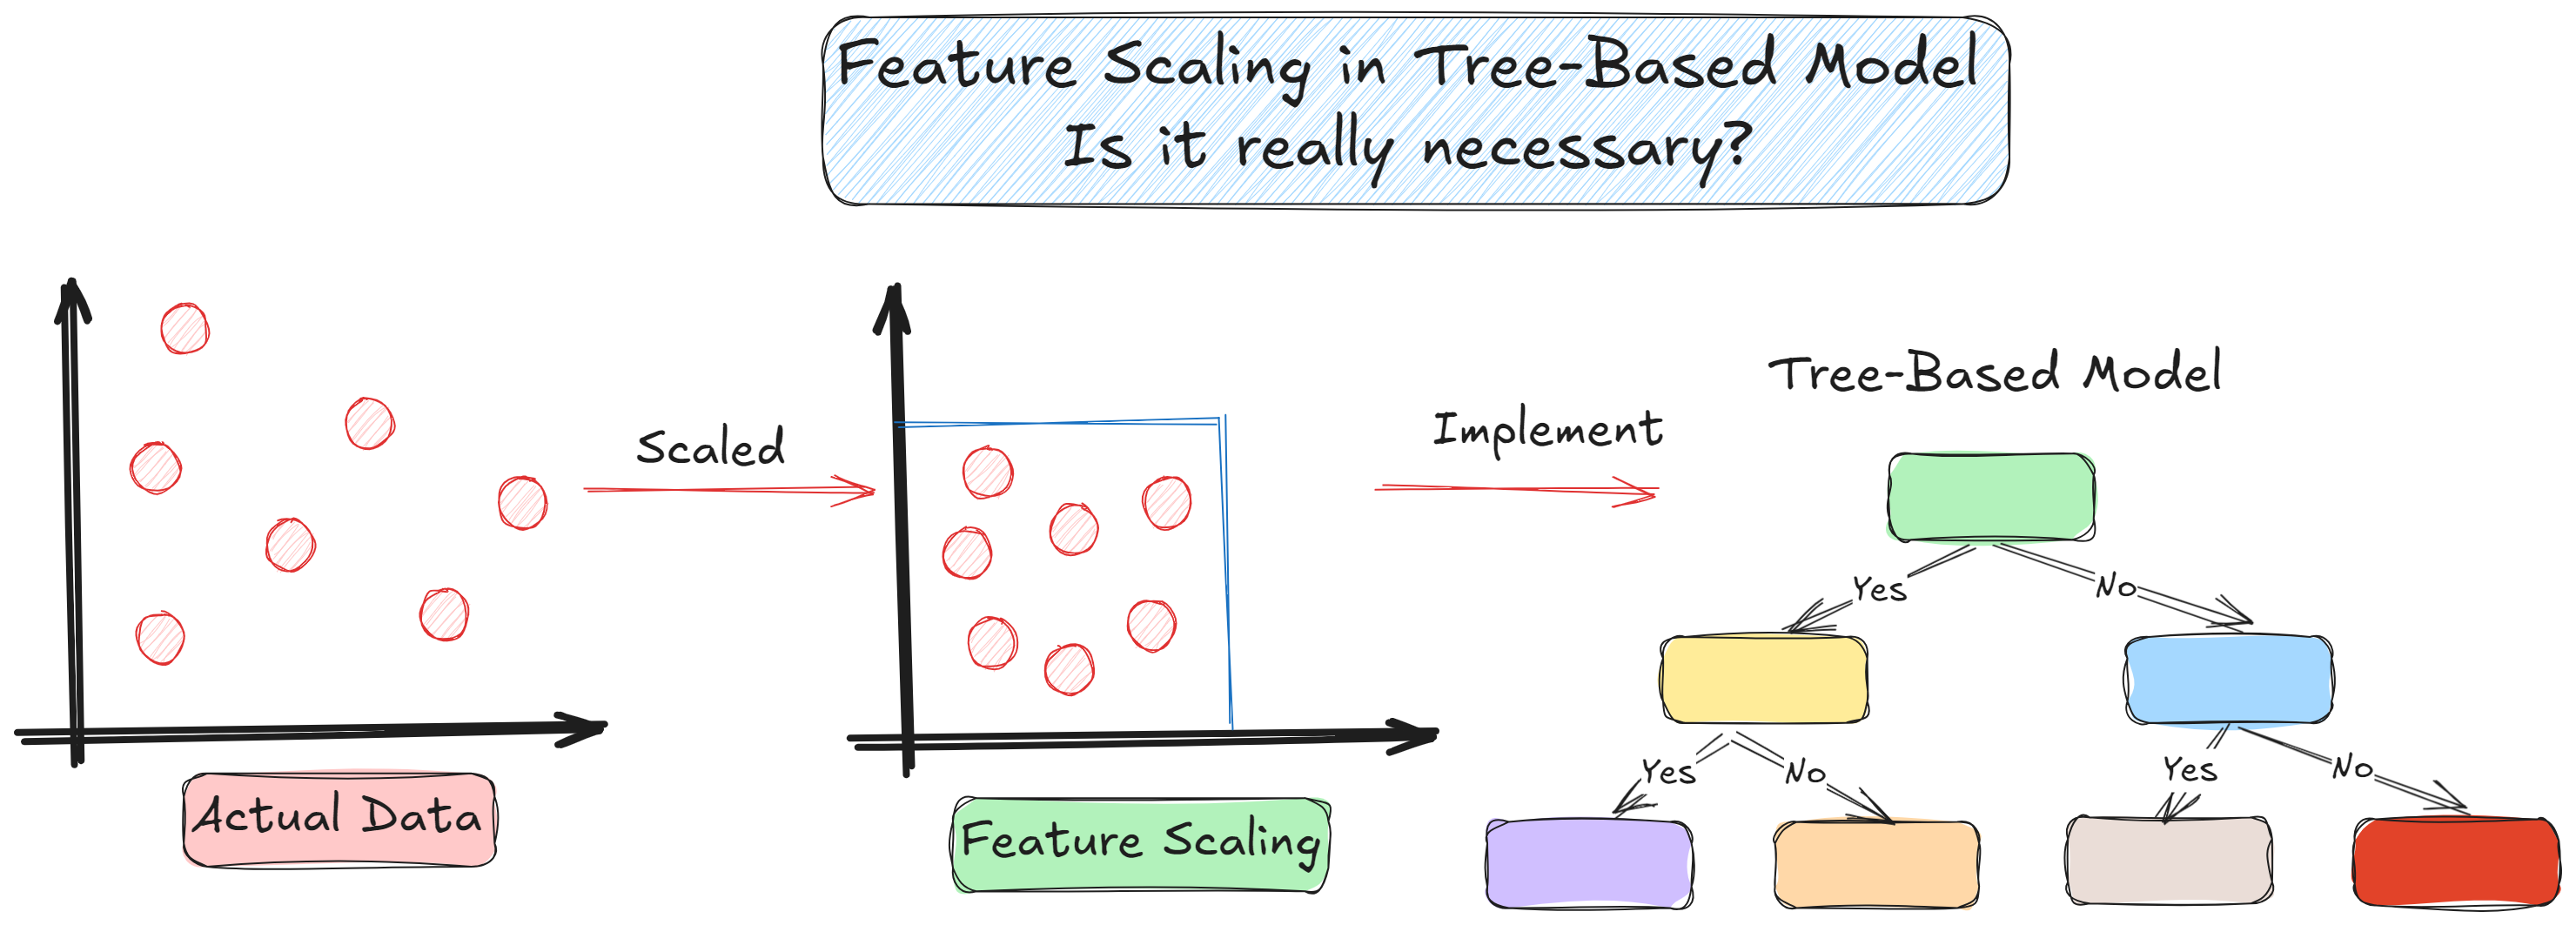

**❓ Question:** Why is feature scaling more necessary for distance based models than tree-based models?

**❕Answer:** Distance-based models rely heavily on the absolute magnitude of feature values to calculate distances between data points, while tree-based models only care about the relative ordering of values within a feature and are not affected by the absolute scale, making feature scaling largely unnecessary.

## Model Implementation

The `sklearn.ensemble` module has a Random Forest Classifier, a Random Forest Regressor, and a Random Trees Embedding ensemble:

1. `RandomForestClassifier`: Creates a set of decision trees from a randomly selected subset of the training set then collects votes from the different decision trees. The majority vote wins.
2.  `RandomForestRegressor`: Creates multiple decision trees using random subsets of training data and features. Each tree makes a prediction, and the final prediction is the average of all individual tree predictions.
3. `RandomTreesEmbedding`: Creates multiple randomly generated decision trees without training for prediction. Instead, it transforms input data into a higher-dimensional space, mapping each data point to leaf node indices across all trees. This unsupervised transformation can improve performance of subsequent machine learning models by capturing complex non-linear relationships in the original data.

By introducing randomness through both data and feature sampling, the Random Forests reduce overfitting and increases generalization, making them more robust than a single decision tree.

In the case of our Social Media Ad dataset, our goal is classification; we want to determine if a given customer will buy a product or not. Let's use `RandomForestClassifier` with three key parameters:

1. `n_estimators = 10`: This tells the model to create 10 decision trees. More trees can improve accuracy but increase computational cost.
2. `criterion='entropy'`: This specifies how the trees decide where to split data. 'Entropy' measures the impurity of data, helping trees make more informed splits compared to other methods like [Gini impurity](https://victorzhou.com/blog/gini-impurity/).
3. `random_state=42`: This sets a fixed random seed, ensuring reproducible results. Every time you run this code, you'll get the same random tree.

In [8]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate
classifier = RandomForestClassifier(n_estimators=10, criterion = 'entropy', random_state=42)

# Fit
classifier.fit(X_train, y_train)

# Predict
y_pred = classifier.predict(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


## Model Evaluation

Now, let's visualize the decision boundary of our `RandomForestClassifier` trained to predict a binary target using two selected features from a dataset. The example begins by creating or using a dataset and splitting it into training and testing subsets. To focus on a two-dimensional space for visualization, only the first two features, representing "Age" and "Income," are used. The classifier is trained on the training data, and a dense grid of points is created to span the feature space. For each point in the grid, the classifier predicts the target class, enabling the creation of a decision boundary that separates the predicted classes. Using matplotlib, the decision boundary is plotted as a colored contour, with the training and testing data points overlaid for context. This visualization illustrates how the model partitions the feature space and provides insight into its decision-making process.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assume that the RandomForestClassifier has already been trained as `classifier`
# X_train_2D and X_test_2D are extracted as 'Age' and 'EstimatedSalary' from the dataset

# Ensure we have the correct data (2D arrays for Age and EstimatedSalary)
X_train_2D = X_train[['Age', 'EstimatedSalary']].to_numpy()  # Extract Age and EstimatedSalary
X_test_2D = X_test[['Age', 'EstimatedSalary']].to_numpy()

# Step 1: Create a mesh grid to visualize the decision boundary
x_min, x_max = X_train_2D[:, 0].min() - 1, X_train_2D[:, 0].max() + 1
y_min, y_max = X_train_2D[:, 1].min() - 1, X_train_2D[:, 1].max() + 1

# Create mesh grid with small intervals to plot decision boundaries
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# Step 2: Predict the classifier's decision for each point in the grid
Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)  # Reshape the result into a mesh shape

# Step 3: Plot the decision boundary
plt.figure(figsize=(10, 6))

# Plot the decision boundary (colored regions based on predicted class)
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)

# Step 4: Plot training points and test points
# Training points (circle markers)
plt.scatter(X_train_2D[:, 0], X_train_2D[:, 1], c=y_train, edgecolor='k', marker='o', cmap=plt.cm.Paired, label='Training Points')

# Test points (cross markers)
plt.scatter(X_test_2D[:, 0], X_test_2D[:, 1], c=y_test, edgecolor='k', marker='x', cmap=plt.cm.Paired, label='Test Points')

# Step 5: Add labels and title
plt.title('Decision Boundary of Random Forest Classifier')
plt.xlabel('Age')
plt.ylabel('EstimatedSalary')
plt.legend()

# Show the plot
plt.show()


Let's additionally create a confusion matrix for our Random Forest Classification model.

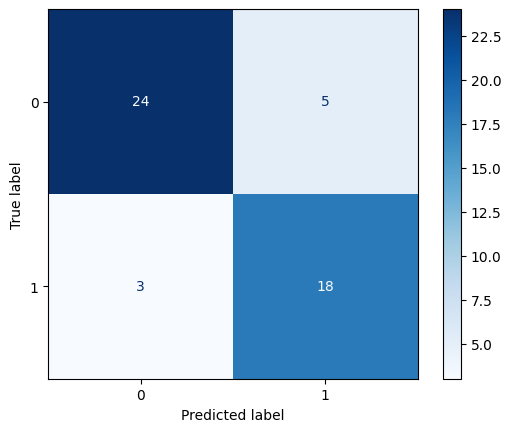

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
disp.plot(cmap = plt.cm.Blues)
plt.show()


✅ **Try it yourself**: Create a Decision Tree Classification model with the goal of solving the same purchase classification problem.

In [ ]:
# Your Code Here

**❓Question:** Between the Random Forest and the Decision Tree, which model seems to perform better? Why?

## Conclusion

💡 **Main idea**: Random Forests help address the overfitting problem of Decision Trees by employing multiple Decision Trees, then using either a majority vote (for classification) or an average (for regression) to determine the final prediction.

### 📑 Sources and Further Reading:

1.  [Climate Prediction-Random Forest](https://www.kaggle.com/code/anandhuh/climate-prediction-random-forest-94-accuracy/notebook) | Anandhu H
2. [Random Forest](https://tikz.net/random-forest/) | Janosh Riebesell
3. [Understanding Random Forests Better Through Visualizations](https://garg-mohit851.medium.com/random-forest-visualization-3f76cdf6456f) | Mohit Garg
4. [Random Forest Regression in Python](https://www.geeksforgeeks.org/random-forest-regression-in-python/) | GeeksforGeeks
5. [Does Random Forest Need Feature Scaling or Normalization?](https://forecastegy.com/posts/does-random-forest-need-feature-scaling-or-normalization/) | Mario Filho
6. [Decision Trees and Random Forests for Beginners](https://www.kaggle.com/code/faressayah/decision-trees-random-forest-for-beginners) | Fares Sayah
7. [How Random Forests Really Work](https://www.kaggle.com/code/jhoward/how-random-forests-really-work) | Jeremy Howard
